# Tech Challenge — Fase 1 | Case NPS Preditivo
## Notebook de Análise Exploratória (EDA) — Estrutura CRISP-DM

**Pós Tech em Data Science — FIAP**  
**Grupo:** _(61)_  
**Data:** _(10/04/2026)_

---

Este notebook segue a metodologia **CRISP-DM** (Cross-Industry Standard Process for Data Mining), que organiza projetos de ciência de dados em seis fases interligadas:

1. **Business Understanding** Entendimento do problema de negócio
2. **Data Understanding** Primeira inspeção dos dados
3. **Data Preparation** Limpeza e preparação
4. **Modeling** Construção do modelo preditivo (etapa opcional do case)
5. **Evaluation** Avaliação dos resultados
6. **Deployment** Proposta de uso prático na empresa

> **Convenção de nomes:** `snake_case` para variáveis e funções. Comentários explicam o *porquê*, não o *o quê*.

## 0. Setup Importações e configurações globais

In [5]:
# Bibliotecas principais
import numpy as np
import pandas as pd
# Plotagem de graficos
import matplotlib.pyplot as plt
import seaborn as sns
# Modelos e auxiliares
import sklearn
import warnings


---
## 1. Business Understanding

### 1.1 Problema de negócio
O e-commerce enfrenta alta variabilidade no NPS e precisa transformar esse indicador reativo em preditivo, antecipando clientes com risco de se tornarem detratores.

### 1.2 Perguntas que este notebook busca responder
- Quais fatores operacionais mais impactam a satisfação do cliente?
- O que mais gera detratores?
- Existe um ponto de ruptura na experiência (ex.: atraso a partir de X dias)?
- Que perfil de cliente tende a ter NPS mais alto ou mais baixo?

### 1.3 Variável-alvo (target)
- **Variável:** `nps_score` (0 a 10)
- **Abordagem escolhida:** _(definir com o grupo — regressão / classificação binária / classificação multiclasse)_
- **Segmentação NPS padrão:** Detratores (0–6), Neutros (7–8), Promotores (9–10)

### 1.4 Critérios de sucesso
- Identificar ao menos 3 drivers operacionais estatisticamente relevantes.
- Produzir insights acionáveis traduzíveis em recomendações de negócio.
- (Opcional) Entregar modelo baseline com métrica de performance adequada.

---
## 2. Data Understanding

Primeira inspeção da base: volume, tipos, valores ausentes e distribuição inicial.

### 2.1 Carga inicial dos dados de NPS


In [6]:
# Ajustar o caminho conforme a estrutura final do repositório
CAMINHO_DADOS_BRUTOS = '/content/desafio_nps_fase_1.csv'

df = pd.read_csv(CAMINHO_DADOS_BRUTOS)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### 2.2 Estrutura geral da base

In [10]:
# Informação do data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [11]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


In [12]:
# Dicionário de dados (conforme enunciado do case), referência rápida para idenfiticação.
dicionario_dados = {
    'customer_id':               'Identificador único do cliente',
    'order_id':                  'Identificador único do pedido',
    'customer_age':              'Idade do cliente',
    'customer_region':           'Região geográfica do cliente',
    'customer_tenure_months':    'Tempo de relacionamento (meses)',
    'order_value':               'Valor total do pedido',
    'items_quantity':            'Quantidade de itens',
    'discount_value':            'Valor de desconto aplicado',
    'payment_installments':      'Número de parcelas',
    'delivery_time_days':        'Tempo total de entrega (dias)',
    'delivery_delay_days':       'Dias de atraso na entrega',
    'freight_value':             'Valor do frete',
    'delivery_attempts':         'Número de tentativas de entrega',
    'customer_service_contacts': 'Contatos do cliente com atendimento',
    'resolution_time_days':      'Tempo de resolução (dias)',
    'complaints_count':          'Número de reclamações',
    'repeat_purchase_30d':       'Recompra em 30 dias (0/1)',
    'csat_internal_score':       'Score interno de satisfação',
    'nps_score':                 'NPS nota do cliente (0 a 10) [TARGET]',
}
pd.DataFrame(dicionario_dados.items(), columns=['coluna', 'descricao'])

,coluna,descricao
0,customer_id,Identificador único do cliente
1,order_id,Identificador único do pedido
2,customer_age,Idade do cliente
3,customer_region,Região geográfica do cliente
4,customer_tenure_months,Tempo de relacionamento (meses)
5,order_value,Valor total do pedido
6,items_quantity,Quantidade de itens
7,discount_value,Valor de desconto aplicado
8,payment_installments,Número de parcelas
9,delivery_time_days,Tempo total de entrega (dias)


### 2.3 Qualidade dos dados

Verificar nulos, duplicatas e consistência básica antes de analisar padrões.

In [13]:
# Valores ausentes por coluna
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [14]:
# Duplicatas
print(f'Linhas duplicadas: {df.duplicated().sum()}')
print(f'Pedidos duplicados (order_id): {df["order_id"].duplicated().sum()}')

Linhas duplicadas: 0
Pedidos duplicados (order_id): 0


### 2.4 Distribuição da target

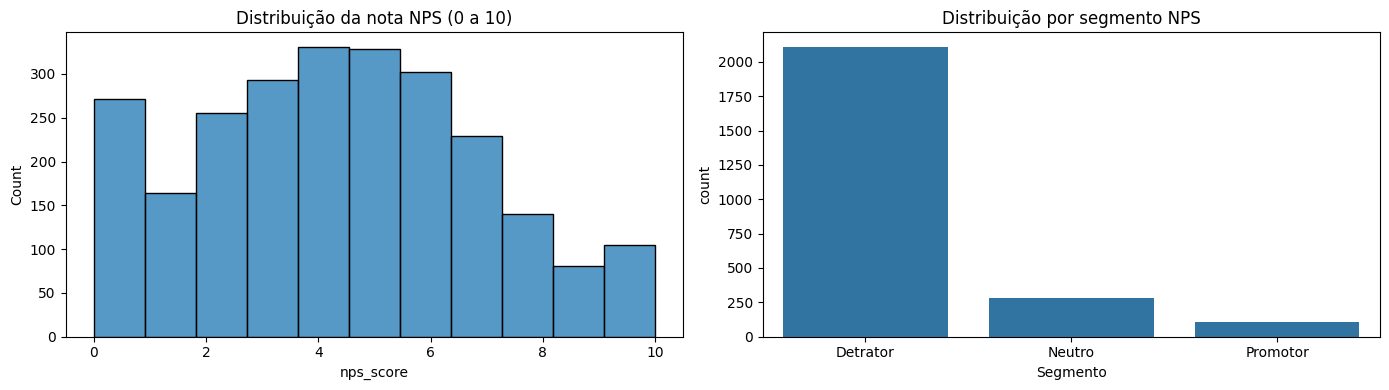


NPS consolidado da base: -80.0


In [15]:
def classificar_nps(nota):
    """Classifica a nota NPS nos três segmentos canônicos."""
    if nota >= 9:
        return 'Promotor'
    if nota >= 7:
        return 'Neutro'
    return 'Detrator'

df['nps_segmento'] = df['nps_score'].apply(classificar_nps)

# Distribuição da nota bruta
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='nps_score', bins=11, ax=axes[0])
axes[0].set_title('Distribuição da nota NPS (0 a 10)')
axes[0].set_xlabel('nps_score')

ordem_segmentos = ['Detrator', 'Neutro', 'Promotor']
sns.countplot(data=df, x='nps_segmento', order=ordem_segmentos, ax=axes[1])
axes[1].set_title('Distribuição por segmento NPS')
axes[1].set_xlabel('Segmento')

plt.tight_layout()
plt.show()

# NPS score
proporcoes = df['nps_segmento'].value_counts(normalize=True) * 100
nps_consolidado = proporcoes.get('Promotor', 0) - proporcoes.get('Detrator', 0)
print(f'\nNPS consolidado da base: {nps_consolidado:.1f}')

---
## 3. Data Preparation

Limpeza, criação de features e separação em grupos lógicos de variáveis.

In [16]:
# Agrupamento lógico de variáveis — facilita análises bivariadas posteriores
variaveis_cliente = ['customer_age', 'customer_region', 'customer_tenure_months']
variaveis_pedido = ['order_value', 'items_quantity', 'discount_value', 'payment_installments']
variaveis_logistica = ['delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts']
variaveis_atendimento = ['customer_service_contacts', 'resolution_time_days', 'complaints_count']
variaveis_negocio = ['repeat_purchase_30d', 'csat_internal_score']

variaveis_numericas = (
    ['customer_age', 'customer_tenure_months']
    + variaveis_pedido + variaveis_logistica + variaveis_atendimento + variaveis_negocio
)

In [18]:
# Criação de features derivadas — hipóteses iniciais a validar

# Flag: entrega atrasada
df['flag_atraso'] = (df['delivery_delay_days'] > 0).astype(int)

# Flag: cliente teve contato com atendimento
df['flag_contato_atendimento'] = (df['customer_service_contacts'] > 0).astype(int)

# Flag: pedido com reclamação
df['flag_com_reclamacao'] = (df['complaints_count'] > 0).astype(int)

# Valor médio por item — proxy de ticket unitário
df['valor_medio_item'] = df['order_value'] / df['items_quantity'].replace(0, np.nan)

df[['flag_atraso', 'flag_contato_atendimento', 'flag_com_reclamacao', 'valor_medio_item']].head()

,flag_atraso,flag_contato_atendimento,flag_com_reclamacao,valor_medio_item
0,1,0,1,34.9325
1,1,0,1,229.4750
2,1,1,1,101.4120
3,1,1,1,151.0950
4,1,1,1,253.0600


---
## 4. Análise Exploratória (EDA)



### 4.1 Análise univariada distribuição das variáveis numéricas

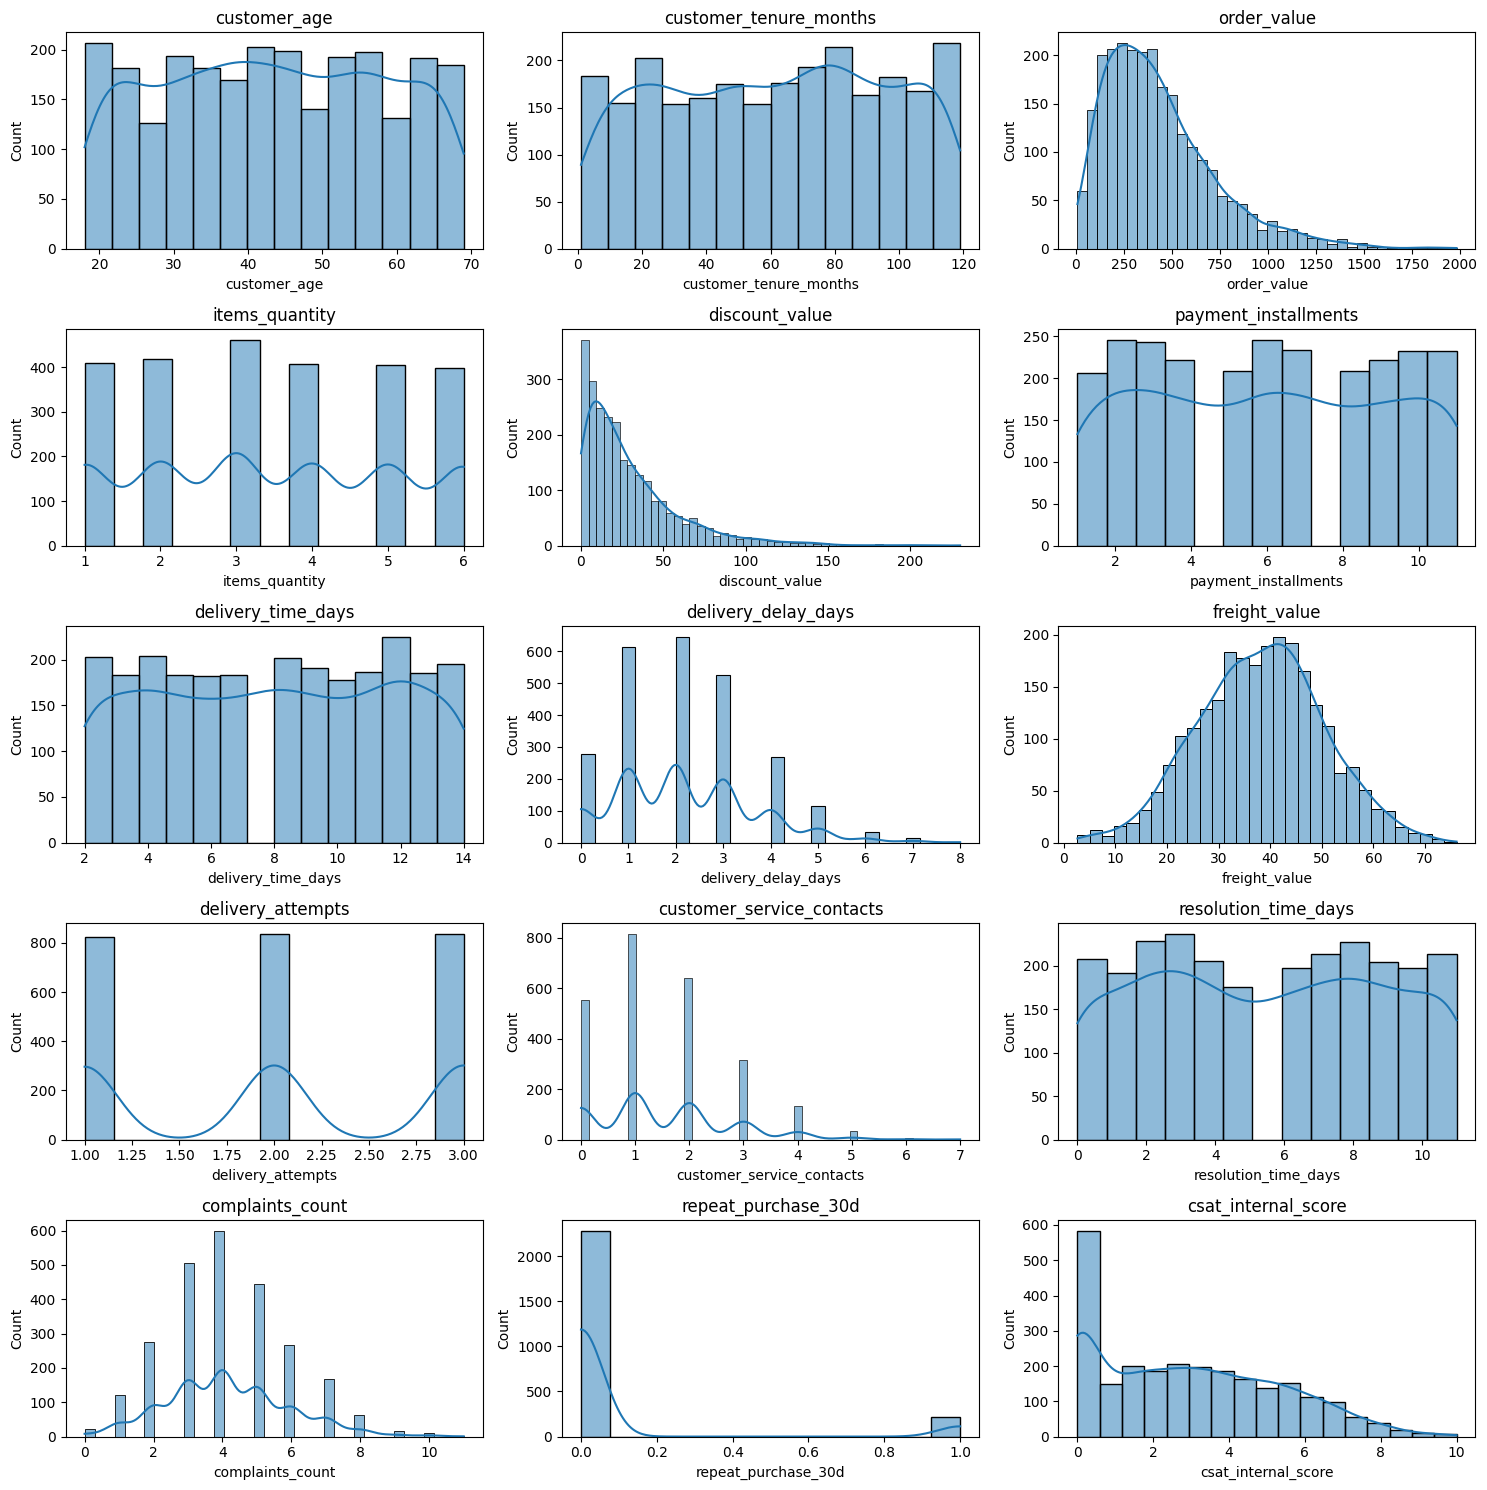

In [19]:
colunas_para_plotar = variaveis_numericas
n_colunas = 3
n_linhas = int(np.ceil(len(colunas_para_plotar) / n_colunas))

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(15, 3 * n_linhas))
axes = axes.flatten()

for i, coluna in enumerate(colunas_para_plotar):
    sns.histplot(data=df, x=coluna, kde=True, ax=axes[i])
    axes[i].set_title(coluna)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2 Análise bivariada cada variável vs. NPS

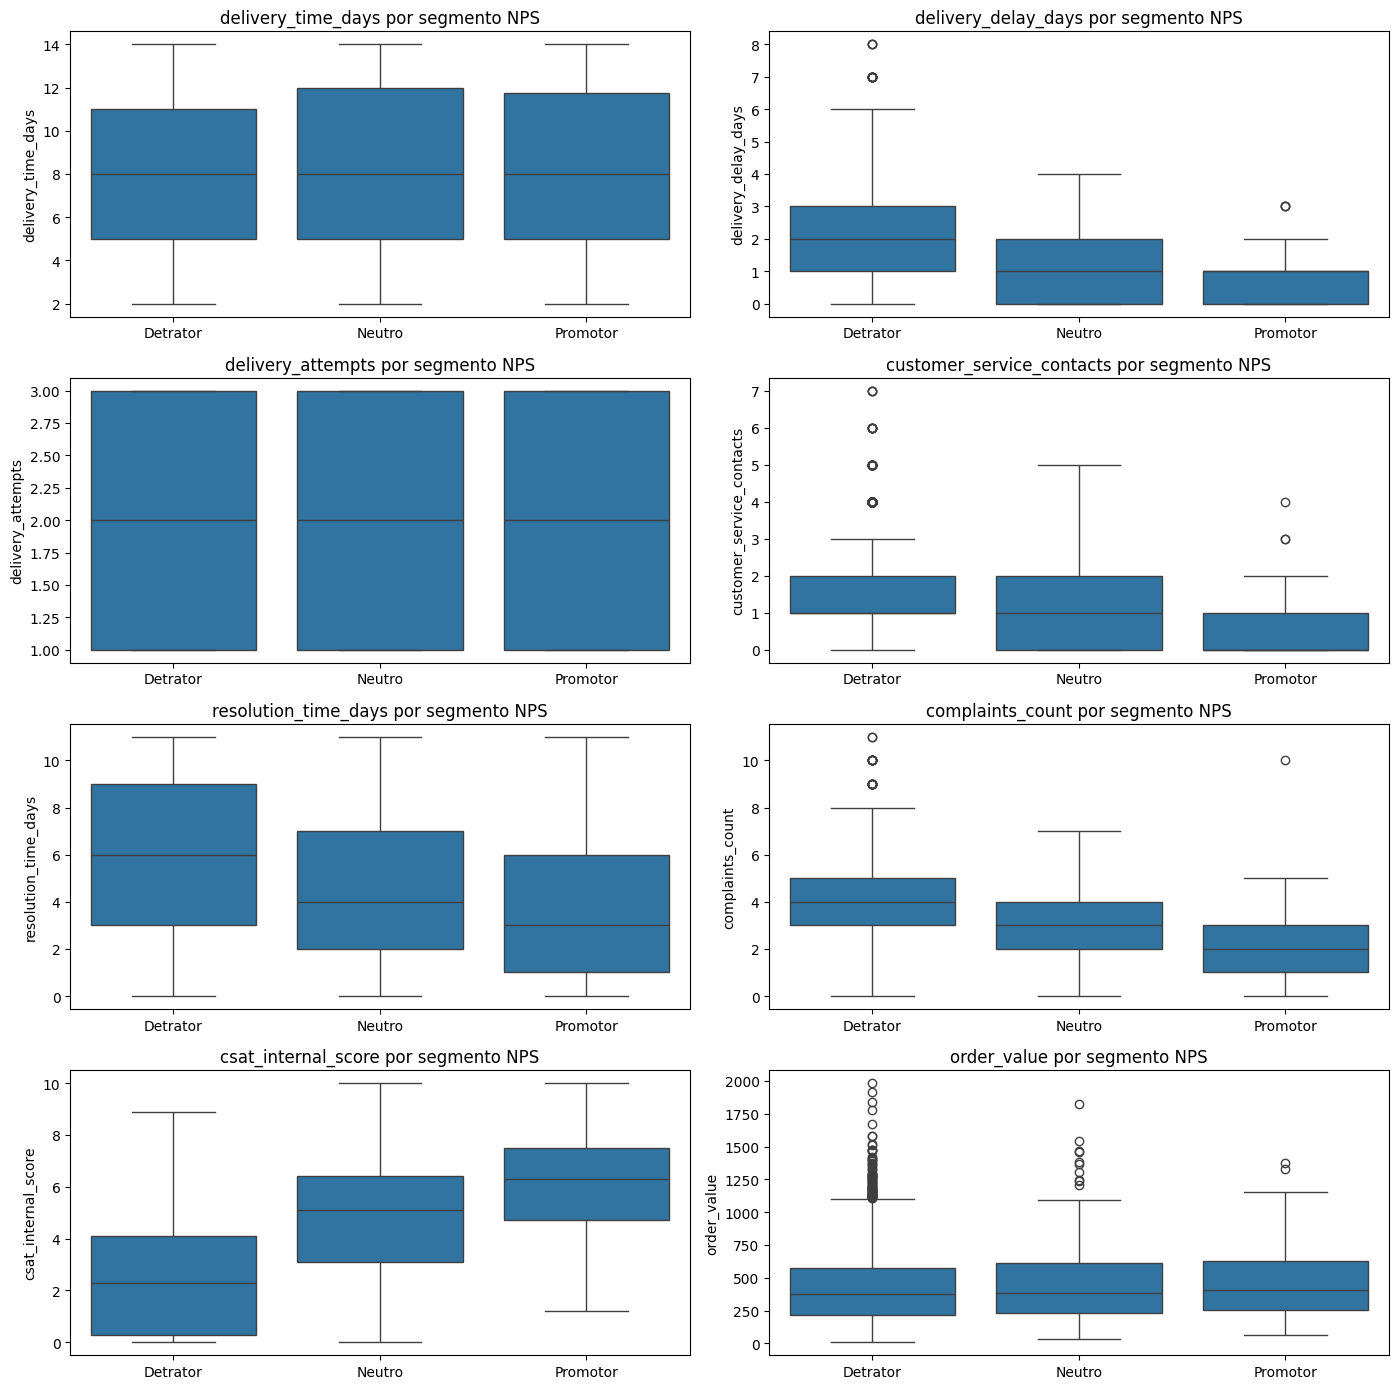

In [20]:
# Boxplots: como cada variável numérica se comporta nos três segmentos NPS
variaveis_para_comparar = [
    'delivery_time_days', 'delivery_delay_days', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count',
    'csat_internal_score', 'order_value'
]

n_colunas = 2
n_linhas = int(np.ceil(len(variaveis_para_comparar) / n_colunas))
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(14, 3.5 * n_linhas))
axes = axes.flatten()

for i, coluna in enumerate(variaveis_para_comparar):
    sns.boxplot(data=df, x='nps_segmento', y=coluna, order=ordem_segmentos, ax=axes[i])
    axes[i].set_title(f'{coluna} por segmento NPS')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 4.3 Correlação entre variáveis numéricas e a target

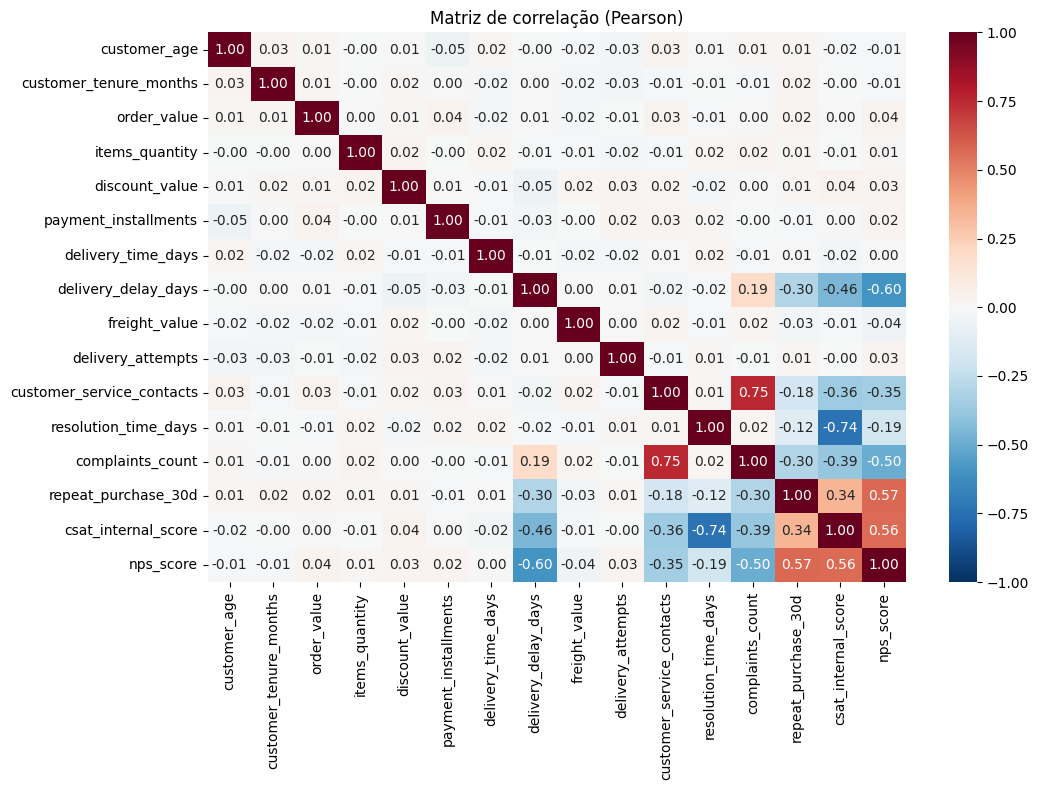


Top variáveis por correlação absoluta com nps_score:
delivery_delay_days          0.597260
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
complaints_count             0.496800
customer_service_contacts    0.350845
resolution_time_days         0.191392
freight_value                0.041087
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
items_quantity               0.011468
customer_age                 0.009936
customer_tenure_months       0.009711
delivery_time_days           0.000925
Name: nps_score, dtype: float64


In [21]:
colunas_correlacao = variaveis_numericas + ['nps_score']
matriz_correlacao = df[colunas_correlacao].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1
)
plt.title('Matriz de correlação (Pearson)')
plt.tight_layout()
plt.show()

# Ranking das variáveis mais correlacionadas com nps_score
correlacao_com_target = (
    matriz_correlacao['nps_score']
      .drop('nps_score')
      .abs()
      .sort_values(ascending=False)
)
print('\nTop variáveis por correlação absoluta com nps_score:')
print(correlacao_com_target)

### 4.4 Análise de detratores — o que mais gera insatisfação?

In [22]:
# Comparar médias entre detratores e promotores para identificar gaps operacionais
perfil_por_segmento = (
    df.groupby('nps_segmento')[variaveis_numericas]
      .mean()
      .T
      .reindex(columns=ordem_segmentos)
)

perfil_por_segmento['gap_detrator_vs_promotor'] = (
    perfil_por_segmento['Detrator'] - perfil_por_segmento['Promotor']
)

perfil_por_segmento.sort_values('gap_detrator_vs_promotor', ascending=False)

nps_segmento,Detrator,Neutro,Promotor,gap_detrator_vs_promotor
complaints_count,4.442390,2.693950,2.272727,2.169662
resolution_time_days,5.694642,4.615658,3.700000,1.994642
delivery_delay_days,2.414889,1.053381,0.718182,1.696707
freight_value,38.298326,38.063381,37.050545,1.247781
customer_service_contacts,1.632053,1.007117,0.672727,0.959326
payment_installments,5.977715,6.277580,5.809091,0.168624
delivery_time_days,7.994310,8.263345,7.936364,0.057946
items_quantity,3.483167,3.313167,3.636364,-0.153196
delivery_attempts,1.997155,2.010676,2.154545,-0.157390
customer_age,43.403035,43.252669,43.627273,-0.224238


### 4.5 Análise por região

In [23]:
nps_por_regiao = (
    df.groupby('customer_region')
      .agg(
          qtd_pedidos=('order_id', 'count'),
          nps_medio=('nps_score', 'mean'),
          atraso_medio=('delivery_delay_days', 'mean'),
      )
      .sort_values('nps_medio', ascending=False)
)
nps_por_regiao

,qtd_pedidos,nps_medio,atraso_medio
customer_region,,,
Sul,521,4.490979,2.168906
Nordeste,485,4.421649,2.185567
Norte,506,4.382609,2.144269
Sudeste,520,4.373846,2.217308
Centro-Oeste,468,4.209829,2.222222


### 4.6 Pontos de ruptura na experiência

Investigar **a partir de qual valor** uma variável operacional começa a derrubar a nota NPS de forma mais acentuada. Útil para definir SLAs internos baseados em dados.

In [24]:
# Exemplo: NPS médio por faixa de atraso
faixas_atraso = pd.cut(
    df['delivery_delay_days'],
    bins=[-0.1, 0, 1, 3, 7, 15, np.inf],
    labels=['Sem atraso', '1 dia', '2-3 dias', '4-7 dias', '8-15 dias', '15+ dias']
)

nps_por_faixa_atraso = (
    df.assign(faixa=faixas_atraso)
      .groupby('faixa', observed=True)
      .agg(qtd=('nps_score', 'count'), nps_medio=('nps_score', 'mean'))
)
nps_por_faixa_atraso

,qtd,nps_medio
faixa,,
Sem atraso,277,6.856679
1 dia,615,5.546179
2-3 dias,1171,4.067549
4-7 dias,434,2.011982
8-15 dias,3,0.000000
